# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

The dataset collected is related to 17 campaigns that occurred between May 2008 and November 2010, corresponding to a total of 79354 contacts. 

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix, auc, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.utils import parallel_backend

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')


In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# 1. Count of missing values (considering 'unknown' and 'nonexistent' as missing)
print("Count of missing values:")
missing_value_counts = (df.isin(['unknown',"nonexistent"])).sum()
print(missing_value_counts[missing_value_counts > 0])


#Count not previously contacted in pdays(999 means not previously contacted)
print("Count of not previously contacted:")
not_previously_contacted_count = (df["pdays"] == 999).sum()
print(not_previously_contacted_count)

# 2. Data type coercion

# Convert categoricals to category dtype
categorical_cols = ["job", "marital", "education","default", "housing", "loan", "contact", "month", 'day_of_week', 'poutcome', "y"]
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Coerce numerics to numeric dtype, setting errors='coerce' to convert non-numeric values to NaN for easier handling later on.
numeric_cols = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Coerce binary variables to 1/0 integers for easier modeling later on. 
binary_mapping = {'no': 0, 'yes': 1}
binary_cols = ['default', 'housing', 'loan', 'y']

for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].map(binary_mapping)


# Replace 'unknown' and 'nonexistent' with nan for easier handling of missing values
df.replace(['unknown', 'nonexistent'], np.nan, inplace=True)

# Replace pdays==999 with nan to indicate missing values for days passed since last contact 
df["pdays"] = df["pdays"].replace(999, np.nan, inplace=True)

Count of missing values:
job            330
marital         80
education     1731
default       8597
housing        990
loan           990
poutcome     35563
dtype: int64
Count of not previously contacted:
39673


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int64   
 1   job             40858 non-null  category
 2   marital         41108 non-null  category
 3   education       39457 non-null  category
 4   default         32591 non-null  float64 
 5   housing         40198 non-null  float64 
 6   loan            40198 non-null  float64 
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  duration        41188 non-null  int64   
 11  campaign        41188 non-null  int64   
 12  pdays           0 non-null      object  
 13  previous        41188 non-null  int64   
 14  poutcome        5625 non-null   category
 15  emp.var.rate    41188 non-null  float64 
 16  cons.price.idx  41188 non-null  float64 
 17  cons.conf.id

### Business objective is to predict whether a client will subscribe to a long-term term deposit.

The goal is to build a predictive model that estimates how likely a contacted client is to subscribe, then use those estimates to target outreach more effectively. It means the bank can cut down on the number of calls it makes, saving agent time and operational costs  without giving up a number of successful subscriptions.

What the institution aims to achieve:

- Increase campaign efficiency: Shift from broad calling to directed marketing by prioritizing clients with the highest predicted propensity to subscribe.
- Optimize resource management: Lower number of contacts (agent time, call volume, and associated costs) by contacting fewer but better qualified prospects.
- Maintain success outcomes: Preserve an approximately similar number of deposit subscriptions even as total outreach decreases  which translates to better ROI across the board.

In [6]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,1,None,0,NaN,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,1,None,0,NaN,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,1,None,0,NaN,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,1,None,0,NaN,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,1,None,0,NaN,1.1,93.994,-36.4,4.857,5191.0,0


### Exploratory Data Analysis

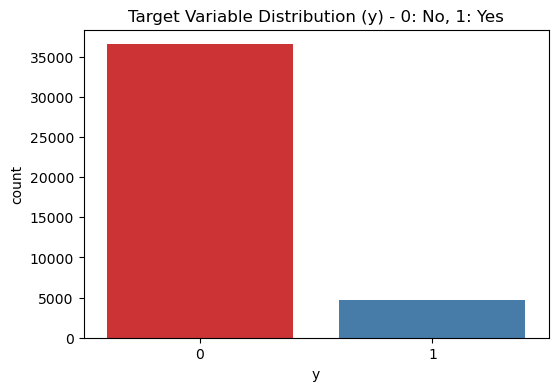

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='y', order=[0, 1], palette='Set1')
plt.title('Target Variable Distribution (y) - 0: No, 1: Yes')
plt.show()

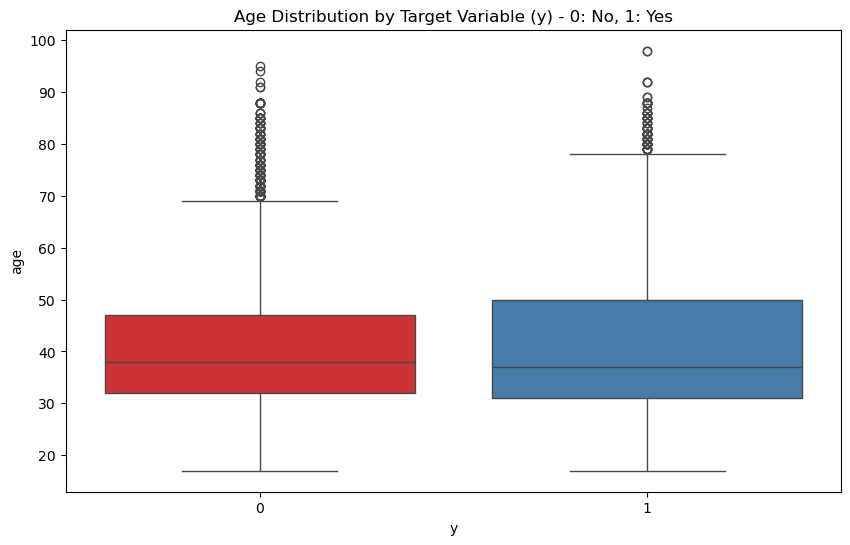

In [10]:
# Plot Numerical Features vs Target
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='y', y='age', order=[0, 1], palette='Set1')
plt.title('Age Distribution by Target Variable (y) - 0: No, 1: Yes')
plt.show()

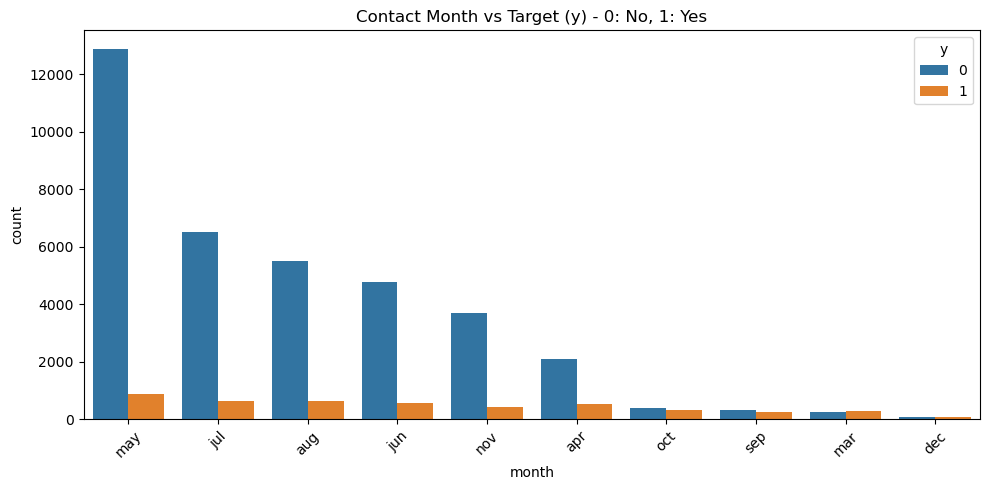

In [8]:
# Plot Categorical Feature vs Target
plt.figure(figsize=(10, 5))
sort_order = df['month'].value_counts().index

sns.countplot(data=df, x='month', hue='y', order=sort_order)
plt.title('Contact Month vs Target (y) - 0: No, 1: Yes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [11]:
features = ["age","job", "marital", "education","default", "housing", "loan"]
X = df[features].copy()
y = df["y"]

numeric_features = ["age"]
categorical_features = ["job", "marital", "education", "default", "housing", "loan"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)

X_processed = preprocessor.fit_transform(X)
print("Processed feature shape:", X_processed.shape)

Processed feature shape: (41188, 28)


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target distribution:\n", y_train.value_counts(normalize=True))
print("Test target distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (32950, 28)
Test set shape: (8238, 28)
Training target distribution:
 y
0    0.887344
1    0.112656
Name: proportion, dtype: float64
Test target distribution:
 y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

The dataset is highly imbalanced:
- no: 88.7%
- yes: 11.3%

Any model we build should beat 88.7% accuracy to be considered useful. But accuracy can be a misleading metric with imbalanced classes like this. Precision, recall, F1, and AUC metrics will give a much better picture.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [13]:
# Train a simple logistic regression model as a baseline
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_pred_proba = lr.predict_proba(X_test)[:, 1]
lr_accuracy_score = accuracy_score(y_test, y_pred)
lr_auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"Logistic Regression - Accuracy: {lr_accuracy_score:.4f}")
print(f"Logistic Regression - AUC: {lr_auc_score:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression - Accuracy: 0.8874
Logistic Regression - AUC: 0.6219
Classification Report:
               precision    recall  f1-score   support

           0       0.89      1.00      0.94      7310
           1       0.00      0.00      0.00       928

    accuracy                           0.89      8238
   macro avg       0.44      0.50      0.47      8238
weighted avg       0.79      0.89      0.83      8238

Confusion Matrix:
 [[7310    0]
 [ 928    0]]


### Problem 9: Score the Model

What is the accuracy of your model?

##### Results & Analysis

- Accuracy: 0.8874 (88.7%)

- AUC: 0.6219

Confusion Matrix:
 [[7310    0]
 [ 928    0]]

The model achieves 88.73% accuracy which is identical to the baseline.

This confusion matrix represents the model that has failed to learn the positive class. The model is essentially predicting "Negative" (0) for every single case.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Define models 
models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=42)),
    'KNN': (KNeighborsClassifier()),
    'DecisionTree': (DecisionTreeClassifier(random_state=42)),
    'SVM': (SVC())
}
results = []

# Train and evaluate each model
for name, model in models.items():
    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[('preprocess', preprocessor), (name, model)])

    # Fit the model and time it
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Evaluate on training and test sets
    train_score = pipeline.score(X_train, y_train)
    test_score = pipeline.score(X_test, y_test)
    
    # Append the results
    results.append([name, train_time, train_score, test_score])

# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Train Time', 'Train Score', 'Test Score'])
results_df.set_index('Model', inplace=True)

# Display the DataFrame
print(results_df)

                    Train Time  Train Score  Test Score
Model                                                  
LogisticRegression    0.107436     0.887344    0.887351
KNN                   0.074736     0.890197    0.880796
DecisionTree          0.118101     0.908012    0.872663
SVM                  29.127970     0.887891    0.886866


Accuracy: All models are hovering right around the 88.7%, which  aligns with our earlier baseline analysis. 

- The Decision Tree has the highest training accuracy (90.8%) but the lowest test accuracy (87.2%). This indicates that the tree is likely overfitting.

- The SVM model is the slowest (over 29 seconds) compared to fractions of a second for the other models.

- The KNN model can be slower at prediction.

- Logistic Regression tends to be fast and stable as a baseline.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Define models and their hyperparameters
models = {
    'LogisticRegression': (
            LogisticRegression(max_iter=1000, random_state=42), 
            {
                'LogisticRegression__C': [0.1, 1, 10], 
                'LogisticRegression__class_weight': [None, 'balanced']
            }
    ),
    'KNN': (
            KNeighborsClassifier(), 
            {
                'KNN__n_neighbors': [3, 5, 7],
                'KNN__weights': ['uniform', 'distance']
            }
    ),
    'SVM': (
            SVC(random_state=42), 
            {
                'SVM__C': [0.1, 1, 10], 
                'SVM__kernel': ['linear', 'rbf'],
                'SVM__class_weight': [None, 'balanced']
            }
    ),
    'DecisionTree': (
            DecisionTreeClassifier(random_state=42), 
            {
                'DecisionTree__max_depth': [3, 5, 10, 15, 20],
                'DecisionTree__min_samples_leaf': [1, 5, 10, 20],
                'DecisionTree__class_weight': [None, 'balanced']
            }
        )
}

results = []
best_models = {}

# Train and evaluate each model
for name, (model, params) in models.items():
    # Create a pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[('preprocess', preprocessor), (name, model)])
    
    # Perform grid search
    grid_search = GridSearchCV(pipeline, param_grid=params, cv=5, scoring='f1', n_jobs=-1)

    # Fit the model and time it
    start_time = time.time()

    # Threading backend avoids child-process cleanup warnings in notebooks
    with parallel_backend("threading", n_jobs=-1):
        grid_search.fit(X_train, y_train)

    train_time = time.time() - start_time
    y_pred = grid_search.predict(X_test)
    
    # Get the best estimator
    best_model = grid_search.best_estimator_
    
    # Evaluate on training and test sets
    train_score = best_model.score(X_train, y_train)
    test_score = best_model.score(X_test, y_test)
    f1 = f1_score(y_test, y_pred)

    # Append the results
    results.append([name, train_time, train_score, test_score, f1, grid_search.best_params_])
    best_models[name] = grid_search

# Create the results DataFrame
results_df = pd.DataFrame(results, columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy', 'Test F1 Score', 'Best Params'])
results_df.set_index('Model', inplace=True)


In [16]:
# Display the DataFrame
print(results_df[['Train Time', 'Train Accuracy', 'Test Accuracy', 'Test F1 Score']])
print(results_df[["Best Params"]].to_string(index=True))

#Best Model by F1 Score and its Classification Report
best_model = results_df['Test F1 Score'].idxmax()
print(f"\nBest Model by F1: {best_model} (F1 = {results_df.loc[best_model, 'Test F1 Score']})")
y_pred_best = best_models[best_model].predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['no', 'yes']))

                     Train Time  Train Accuracy  Test Accuracy  Test F1 Score
Model                                                                        
LogisticRegression     5.395696        0.614932       0.611313       0.243026
KNN                    6.084465        0.901093       0.863923       0.146230
SVM                 1290.791060        0.641123       0.623331       0.243724
DecisionTree          11.538461        0.582610       0.577810       0.239283
                                                                                                                       Best Params
Model                                                                                                                             
LogisticRegression                                   {'LogisticRegression__C': 10, 'LogisticRegression__class_weight': 'balanced'}
KNN                                                                            {'KNN__n_neighbors': 3, 'KNN__weights': 'distance'}
SVM     

### Findings

##### Accuracy vs. F1 Score

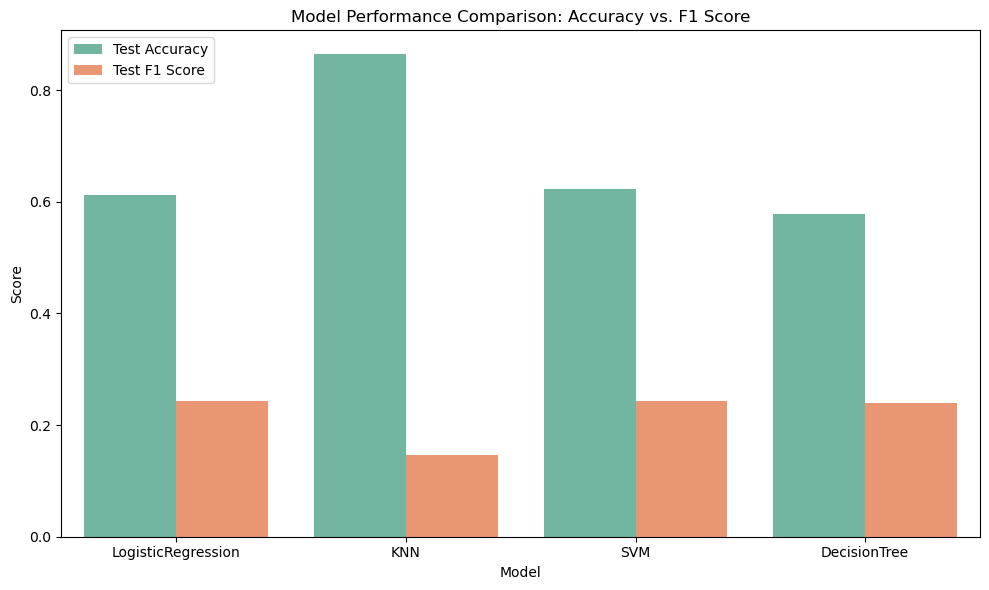

In [17]:
# Plot Model Performance Metrics (Accuracy vs F1)
plot_df = results_df.reset_index()

# Melt the dataframe to easily plot multiple metrics side-by-side
melted_df = pd.melt(plot_df, 
                    id_vars=['Model'], 
                    value_vars=['Test Accuracy', 'Test F1 Score' ], 
                    var_name='Metric', 
                    value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=melted_df, x='Model', y='Score', hue='Metric', palette='Set2')
plt.title('Model Performance Comparison: Accuracy vs. F1 Score')
plt.ylabel('Score')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

Because 89% of clients decline the subscription, models can achieve high accuracy simply by guessing "no" every time. The F1 Score reveals the truth: Logistic Regression, SVM and Decision Trees (using balanced class weights) successfully capture the "yes" subscriptions, while KNN almost completely fails to identify them.

##### Training time

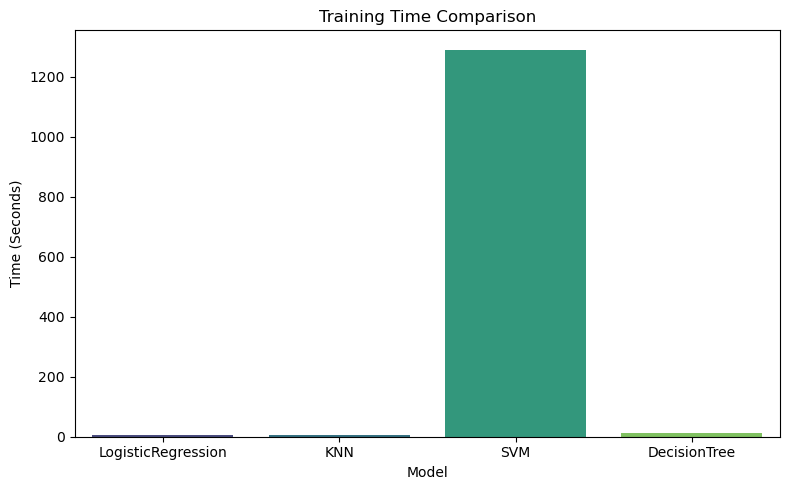

In [18]:
# Plot Training Time
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df, x='Model', y='Train Time', palette='viridis')
plt.title('Training Time Comparison')
plt.ylabel('Time (Seconds)')
plt.tight_layout()
plt.show()

The Training Time comparison shows that SVM is very slow for this dataset size, especially when searching for hyperparameters, without offering performance gain.

##### Decision Tree Feature Importances


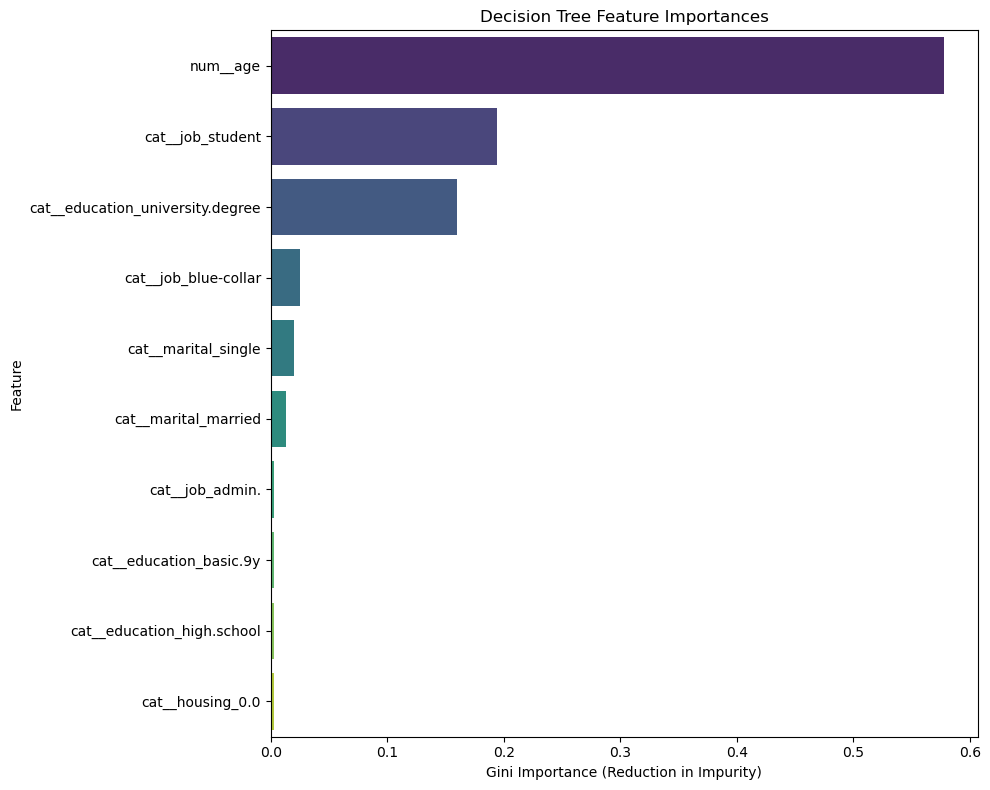


Top 10 Most Important Features:
                         Feature  Importance
                        num__age    0.577953
                cat__job_student    0.194300
cat__education_university.degree    0.159579
            cat__job_blue-collar    0.024851
             cat__marital_single    0.019589
            cat__marital_married    0.013337
                 cat__job_admin.    0.002696
         cat__education_basic.9y    0.002670
      cat__education_high.school    0.002611
                cat__housing_0.0    0.002414


In [ ]:
# Plot Decision Tree Feature Importances

#Extract the best Decision Tree pipeline from  GridSearch results
best_dt_pipeline = best_models['DecisionTree'].best_estimator_

#Extract the trained model and the preprocessor from the pipeline
dt_model = best_dt_pipeline.named_steps['DecisionTree']
preprocessor = best_dt_pipeline.named_steps['preprocess']

#Get the feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Extract the feature importances
importances = dt_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance and filter out features with zero importance
importance_df = importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)
top_importance = importance_df[importance_df['Importance'] > 0]

#Plot the Feature Importances
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_importance, palette='viridis')

plt.title('Decision Tree Feature Importances')
plt.xlabel('Gini Importance (Reduction in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#Print the top 10 features
print("\nTop 10 Most Important Features:")
print(top_importance.head(10).to_string(index=False))

Age (Importance: 0.58) is the most important feature for categorizing clients.

Being a student and having a university degree provide the next highest information, showing these specific groups behave distinctively compared to the rest of the population.

All remaining features contribute much less.

The Decision Tree’s predictions are driven primarily by age, with additional importance coming from student status and university education, while other demographics contribute marginally in this fitted model.

##### ROC Curves


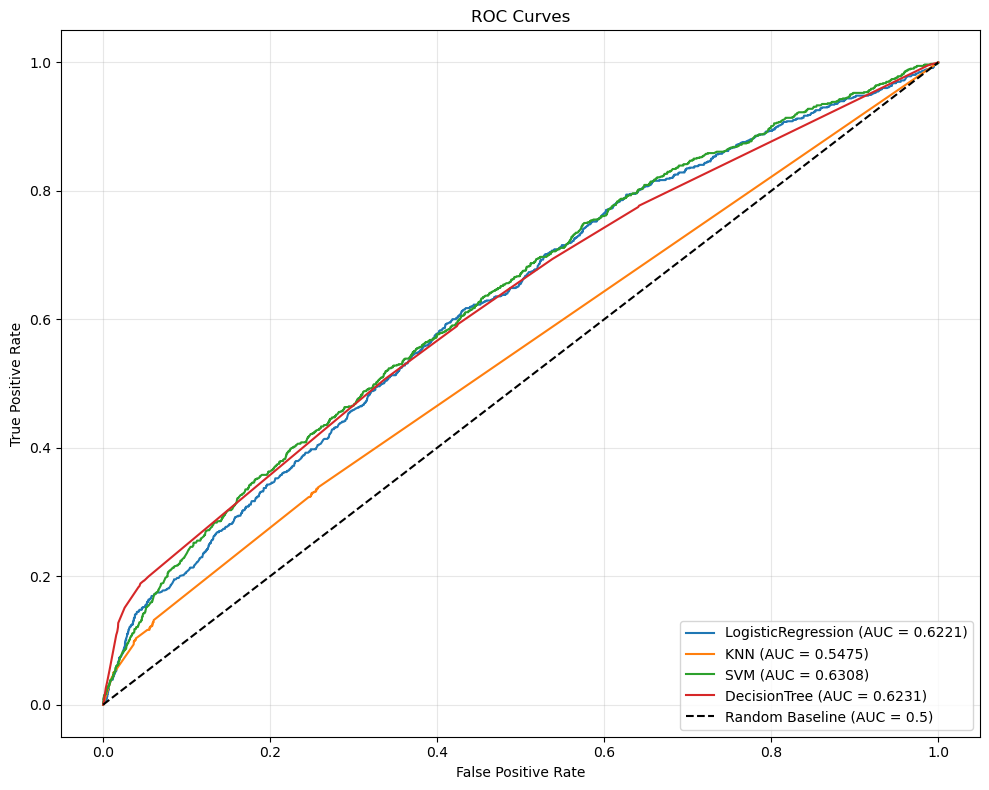

In [48]:
# Plot the ROC Curves
plt.figure(figsize=(10, 8))

for name, grid in best_models.items():
    best_model = grid.best_estimator_
    
    if name == 'SVM':
        # decision_function returns a score, we can use it for ROC
        scores = best_model.decision_function(X_test)
    else:
        scores = best_model.predict_proba(X_test)[:, 1]
        
    # Calculate False Positive Rate, True Positive Rate, and AUC
    fpr, tpr, thresholds = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

# Add the random baseline
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random Baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

 ROC curves plot suggests that LogisticRegression and SVM with the best AUC offer the strongest ability for identifying likely subscribers.

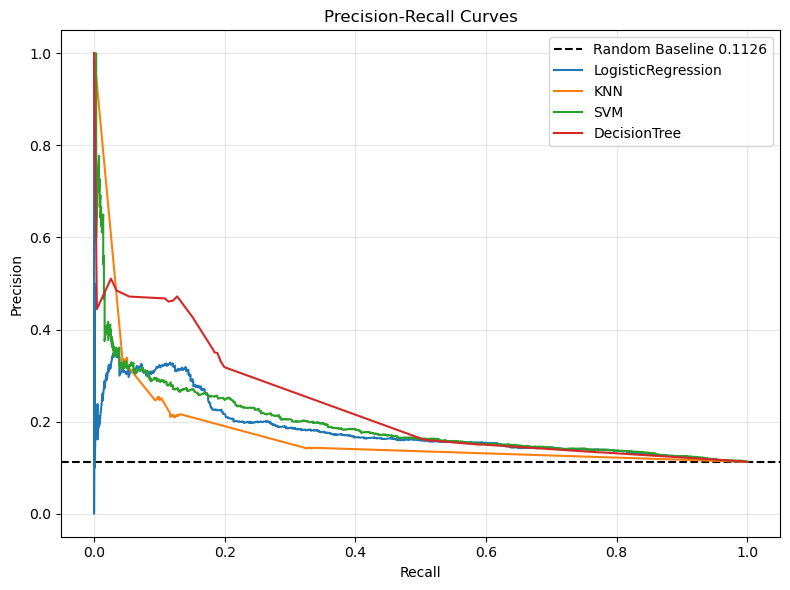

In [46]:
#Plot Precision-Recall Curves
plt.figure(figsize=(8, 6))

# The baseline for a PR curve is the proportion of positive cases in the dataset
baseline = np.mean(y_test.astype(int))
plt.axhline(y=baseline, color='black', linestyle='--', label=f'Random Baseline {baseline:.4f}')

for name, grid in best_models.items():
    best_model = grid.best_estimator_

    if name == 'SVM':
        # decision_function returns a score, we can use it for ROC
        scores = best_model.decision_function(X_test)
    else:
        scores = best_model.predict_proba(X_test)[:, 1]
    
    # Calculate Precision, Recall
    precision, recall, _ = precision_recall_curve(y_test.astype(int), scores)
    
    # Plot curve
    plt.plot(recall, precision, label=f'{name}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Our models are slightly beating this 11% baseline, but they are not highly reliable yet. All models converge toward the baseline as recall approaches 1.0, indicating that trying to capture everyone increases false positives and reduces precision.

##### Confusion Matrices

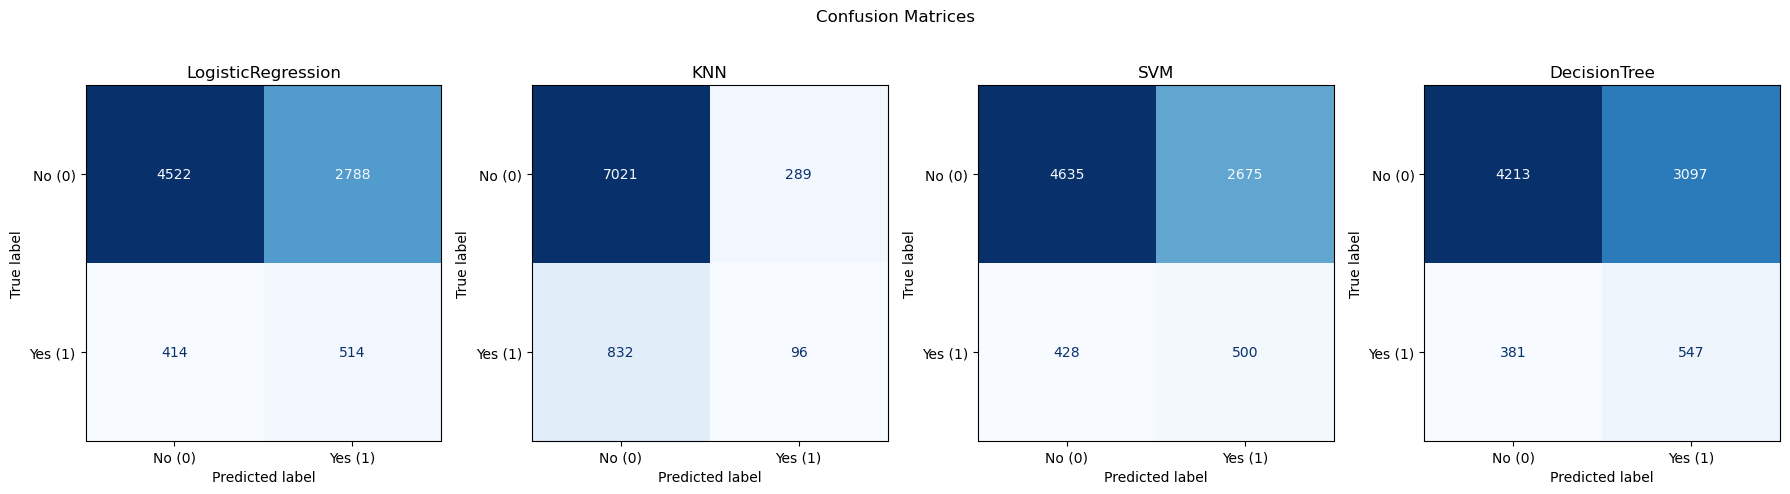

In [49]:
#Plot Confusion Matrices

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for name, grid in best_models.items():
    best_model = grid.best_estimator_

    if name == 'SVM':
        # decision_function returns a score, we can use it for ROC
        scores = best_model.decision_function(X_test)
    else:
        scores = best_model.predict_proba(X_test)[:, 1]

for ax, (name, grid) in zip(axes, best_models.items()):
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    
    # Generate and display confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
    
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}')
    ax.grid(False) 

plt.suptitle('Confusion Matrices')
plt.tight_layout()
plt.show()

LogisticRegression, DecisionTree and SVM catch more "yes" cases but at the cost of many false positives. KNN barely catches anyone as "yes."

##### Recommendations

Do not rely on client demographics alone to build a contact list. The current models would generate too many false positives, wasting agent time on clients unlikely to subscribe.

For the next iteration of modeling, the team should abandon KNN and SVMs. Decision Trees can train  fast, handle missing data well, inherently balance complex non-linear relationships.

Explore more methods which can handle imbalanced, mixed-feature datasets better than the individual classifiers tested here.

##### Next Steps

Rebuild models using the full feature set (all 20 input variables) and compare performance.

Perform feature importance analysis on the expanded model to identify which variables drive subscription, giving the marketing team concrete, actionable targeting criteria.